Clusterização

O agrupamento é uma técnica para dividir os dados em diferentes grupos, na qual os registros em cada grupo são semelhantes uns aos outros. Os grupos podem ser usados diretamente, analisando mais a fundo ou passados como uma característica ou resultado para um modelo de regressão ou classificação.

In [144]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import adjusted_rand_score, silhouette_score

In [145]:
url_mall = "https://raw.githubusercontent.com/JulianaMoretto/Postech-data-analytics/refs/heads/main/Machine-Learning/mall.csv"
mall = pd.read_csv(url_mall)
mall.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [146]:
mall.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [147]:
mall.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


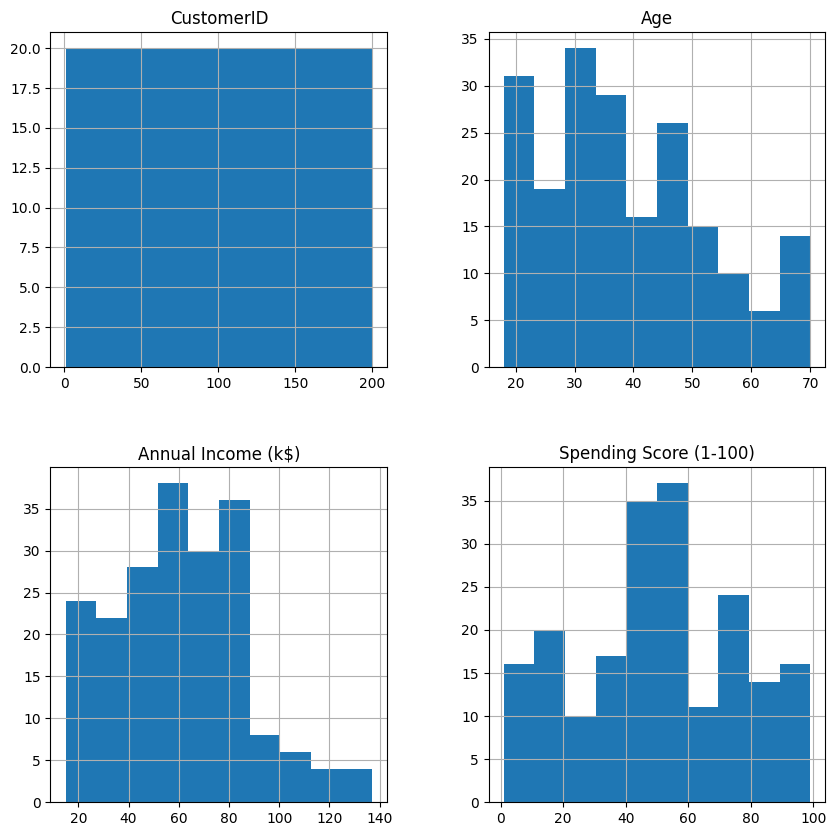

In [148]:
mall.hist(figsize=(10,10))
plt.show()

<Axes: >

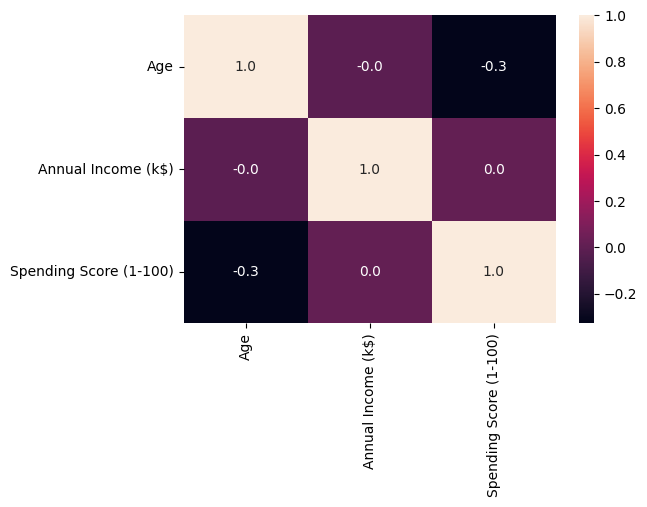

In [149]:
plt.figure(figsize=(6,4))
sns.heatmap(mall[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].corr(method = 'pearson'), annot=True, fmt=".1f") #método de pearson mede a correlação linear (+1 quando uma sobe outra sobe / 0 sem correlação / -1 quando uma sobe outra cai)

In [150]:
mall["Gender"].value_counts()

,count
Gender,
Female,112
Male,88


Boa proporção entre os generos que temos disponíveis em nossos dados.

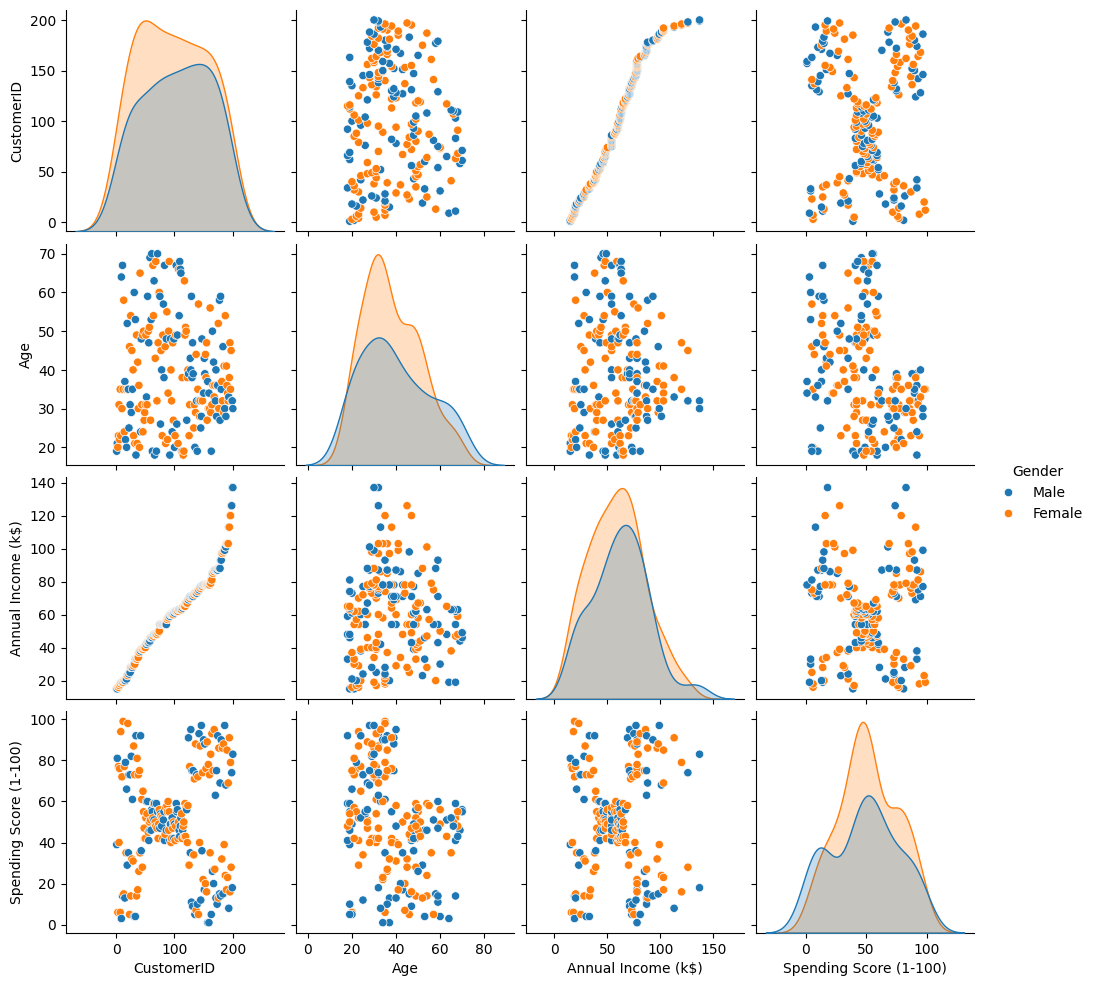

In [151]:
sns.pairplot(mall, hue="Gender")
plt.show()

Aparentemente o Annual Income e o Spending Score permitem alguns agrupamentos dos nossos dados.

In [152]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler #Feature Engineer

StandardScaler - Padronização (Z-score)
* Centraliza em 0
* Mantém outliers
* Ideal para:
  * KMeans
  * Regressão logística
  * SVM
  * PCA

MinMaxScaler - Normalização
* Escala para 0,1
* Sensível a outliers
* Útil para:
  * Redes neurais
  * Visualizações
  * Algoritmos baseados em distância com limite fixo

In [153]:
scaler = StandardScaler()
#scaler = MinMaxScaler()
scaler.fit(mall[['Annual Income (k$)','Spending Score (1-100)']]) #aqui ele calcula a média e desvio padrão de cada variável

#Importante realizar o standard pois Annual Income (k$) tem escala muito maior e o Spending Score (1-100) tem escala limitada, sem ajustar o algoritmo “acha” que renda é mais importante e distâncias ficam distorcidas

StandardScaler()

In [154]:
dados_Escalonados = scaler.transform(mall[['Annual Income (k$)','Spending Score (1-100)']]) #aqui ele pega cada variável e aplica a transformação usando a média e desvio calculado antes

In [155]:
dados_Escalonados

array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992],
       [-1.66266033,  1.00159627],
       [-1.62449091, -1.71591298],
       [-1.62449091,  1.70038436],
       [-1.58632148, -1.83237767],
       [-1.58632148,  0.84631002],
       [-1.58632148, -1.4053405 ],
       [-1.58632148,  1.89449216],
       [-1.54815205, -1.36651894],
       [-1.54815205,  1.04041783],
       [-1.54815205, -1.44416206],
       [-1.54815205,  1.11806095],
       [-1.50998262, -0.59008772],
       [-1.50998262,  0.61338066],
       [-1.43364376, -0.82301709],
       [-1.43364376,  1.8556706 ],
       [-1.39547433, -0.59008772],
       [-1.39547433,  0.88513158],
       [-1.3573049 , -1.75473454],
       [-1.3573049 ,  0.88513158],
       [-1.24279661, -1.4053405 ],
       [-1.24279661,  1.23452563],
       [-1.24279661, -0.7065524 ],
       [-1.24279661,  0.41927286],
       [-1.20462718,

### 1. K-Means

### Sobre o modelo
O **K-Means** é um algoritmo de **clusterização** que divide o espaço multidimensional de dados em **K grupos**, com base na distância dos pontos aos **centróides**. Inicialmente, os centróides são definidos de forma aleatória. Em seguida, o algoritmo calcula a distância de cada ponto ao centróide mais próximo e atualiza esses centróides iterativamente, até que os agrupamentos se estabilizem.

### Hiperparâmetros
- **K (número de clusters)**: principal hiperparâmetro do modelo.  
  - Normalmente definido por meio do **método do Elbow**, que avalia a **soma dos erros quadráticos** para identificar o valor de K que melhor equilibra complexidade e desempenho.

### Vantagens
- Implementação simples  
- Computacionalmente eficiente  
- Funciona bem com medidas de similaridade baseadas em distância  

### Desvantagens
- Difícil definir o valor ideal de K  
- Sensível a outliers  
- Não lida bem com clusters não globulares  


In [156]:
#Definindo o modelo de clusterização K-MEANS com 6 clusters
kmeans = KMeans(n_clusters=6, random_state=0, n_init=10)
#Implementando o kmeans nos dados
kmeans.fit(mall[['Annual Income (k$)','Spending Score (1-100)']])
#Salvando os centroides de cada cluster
centroides = kmeans.cluster_centers_
#Salvando os labels dos clusters para cada exemplo
kmeans_labels = kmeans.predict(mall[['Annual Income (k$)','Spending Score (1-100)']])

In [157]:
#Definindo o modelo de clusterização K-MEANS com 6 clusters
kmeans_escalonados  = KMeans(n_clusters=6, random_state=0, n_init=10)
#Implementando o kmeans nos dados
kmeans.fit(dados_Escalonados)
#Salvando os centroides de cada cluster
centroides_escalonados = kmeans.cluster_centers_
#Salvando os labels dos clusters para cada exemplo
kmeans_labels_escalonado  = kmeans.predict(dados_Escalonados)

In [158]:
dados_Escalonados = pd.DataFrame(dados_Escalonados, columns = ['Annual Income (k$)','Spending Score (1-100)'])

In [159]:
dados_Escalonados.head()

,Annual Income (k$),Spending Score (1-100)
0,-1.738999,-0.434801
1,-1.738999,1.195704
2,-1.700830,-1.715913
3,-1.700830,1.040418
4,-1.662660,-0.395980


In [160]:
dados_Escalonados['Grupos'] = kmeans_labels_escalonado
dados_Escalonados.head()

,Annual Income (k$),Spending Score (1-100),Grupos
0,-1.738999,-0.434801,0
1,-1.738999,1.195704,3
2,-1.700830,-1.715913,0
3,-1.700830,1.040418,3
4,-1.662660,-0.395980,0


In [161]:
mall['Grupos'] = kmeans_labels
mall.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Grupos
0,1,Male,19,15,39,5
1,2,Male,21,15,81,0
2,3,Female,20,16,6,5
3,4,Female,23,16,77,0
4,5,Female,31,17,40,5


In [162]:
pd.Series(kmeans_labels).value_counts()

,count
3,81
2,35
1,28
5,23
0,22
4,11


In [163]:
centroides #espaço tridimensional (salário e score de gasto)

array([[ 25.72727273,  79.36363636],
       [ 78.03571429,  81.89285714],
       [ 88.2       ,  17.11428571],
       [ 55.2962963 ,  49.51851852],
       [108.18181818,  82.72727273],
       [ 26.30434783,  20.91304348]])

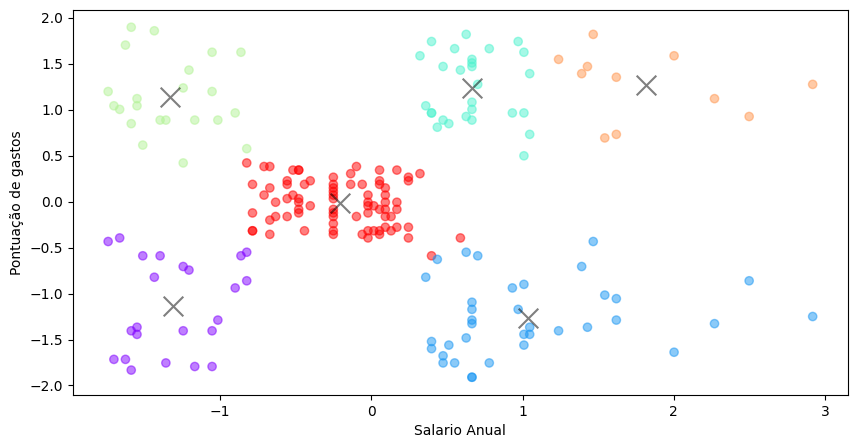

In [164]:
plt.scatter(dados_Escalonados[["Annual Income (k$)"]], dados_Escalonados[["Spending Score (1-100)"]], c=kmeans_labels_escalonado,alpha=0.5,cmap="rainbow")
plt.xlabel('Salario Anual')
plt.ylabel('Pontuação de gastos')
plt.scatter(centroides_escalonados[:,0], centroides_escalonados[:,1], c='black', marker='x',s=200, alpha=0.5)
plt.rcParams['figure.figsize'] = (10, 5)
plt.show()

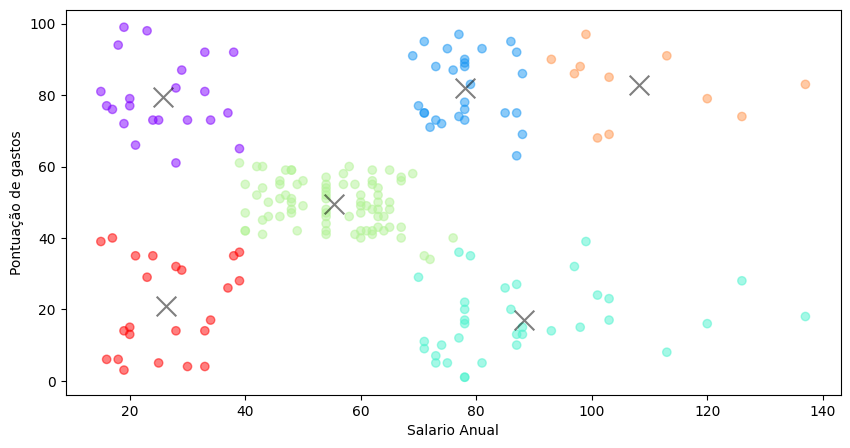

In [165]:
plt.scatter(mall[["Annual Income (k$)"]], mall[["Spending Score (1-100)"]], c=kmeans_labels,alpha=0.5,cmap="rainbow")
plt.xlabel('Salario Anual')
plt.ylabel('Pontuação de gastos')
plt.scatter(centroides[:,0], centroides[:,1], c='black', marker='x',s=200, alpha=0.5)
plt.rcParams['figure.figsize'] = (10, 5)
plt.show()

In [166]:
# Lista com a quantidade de clusters que iremos testar
k = list(range(1, 10))
print(k)

[1, 2, 3, 4, 5, 6, 7, 8, 9]


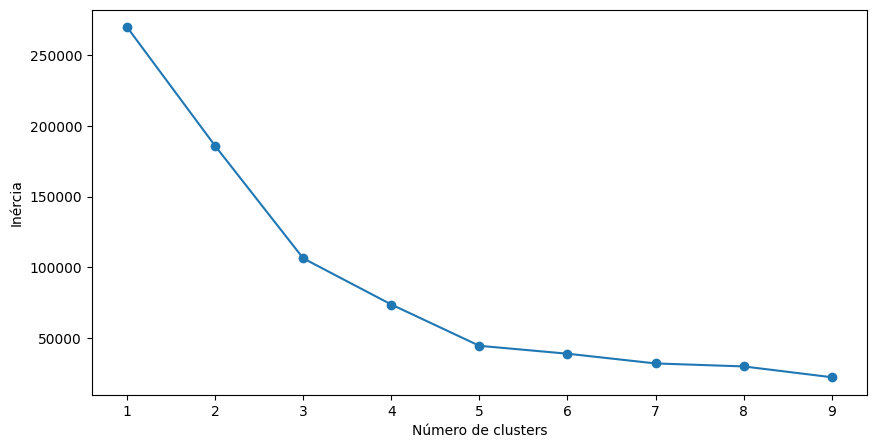

In [167]:
# Armazena o SSE (soma dos erros quadraticos) para cada quantidade de k
sse = []

# Roda o K-means para cada k fornecido
for i in k:
    kmeans = KMeans(n_clusters=i, random_state=0)
    kmeans.fit(mall[['Annual Income (k$)','Spending Score (1-100)']])
    sse.append(kmeans.inertia_) #calculo do erro do k-mens (mudar o centroide dos dados)

plt.rcParams['figure.figsize'] = (10, 5)
# Plota o gráfico com a soma dos erros quadraticos
plt.plot(k, sse, '-o')
plt.xlabel(r'Número de clusters')
plt.ylabel('Inércia')
plt.show()

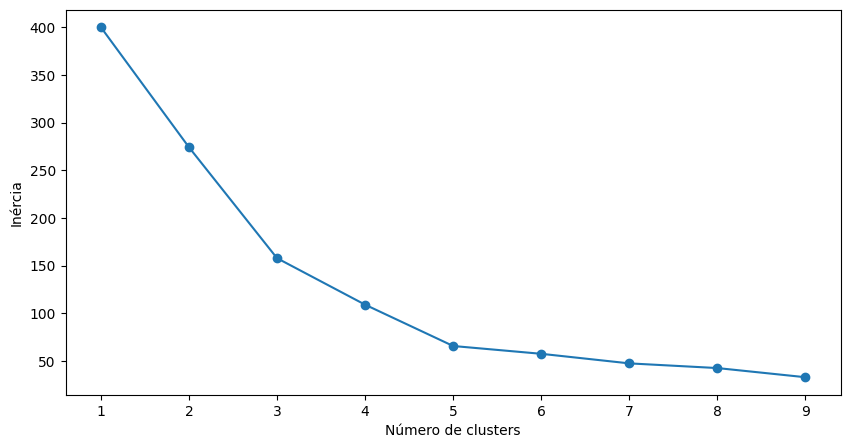

In [168]:
# Armazena o SSE (soma dos erros quadraticos) para cada quantidade de k
sse = []

# Roda o K-means para cada k fornecido
for i in k:
    kmeans = KMeans(n_clusters=i, random_state=0)
    kmeans.fit(dados_Escalonados[['Annual Income (k$)','Spending Score (1-100)']])
    sse.append(kmeans.inertia_) #calculo do erro do k-mens (mudar o centroide dos dados)

plt.rcParams['figure.figsize'] = (10, 5)
# Plota o gráfico com a soma dos erros quadraticos
plt.plot(k, sse, '-o')
plt.xlabel(r'Número de clusters')
plt.ylabel('Inércia')
plt.show()

In [169]:
#Definindo o modelo de clusterização K-MEANS com 6 clusters
kmeans = KMeans(n_clusters=5, random_state=0, n_init=10)
#Implementando o kmeans nos dados
kmeans.fit(mall[['Annual Income (k$)','Spending Score (1-100)']])
#Salvando os centroides de cada cluster
centroides = kmeans.cluster_centers_
#Salvando os labels dos clusters para cada exemplo
kmeans_labels = kmeans.predict(mall[['Annual Income (k$)','Spending Score (1-100)']])

In [170]:
#Definindo o modelo de clusterização K-MEANS com 6 clusters
kmeans_escalonados  = KMeans(n_clusters=5, random_state=0, n_init=10)
#Implementando o kmeans nos dados
kmeans_escalonados.fit(dados_Escalonados)
#Salvando os centroides de cada cluster
centroides_escalonados = kmeans_escalonados.cluster_centers_
#Salvando os labels dos clusters para cada exemplo
kmeans_labels_escalonado  = kmeans_escalonados.predict(dados_Escalonados)

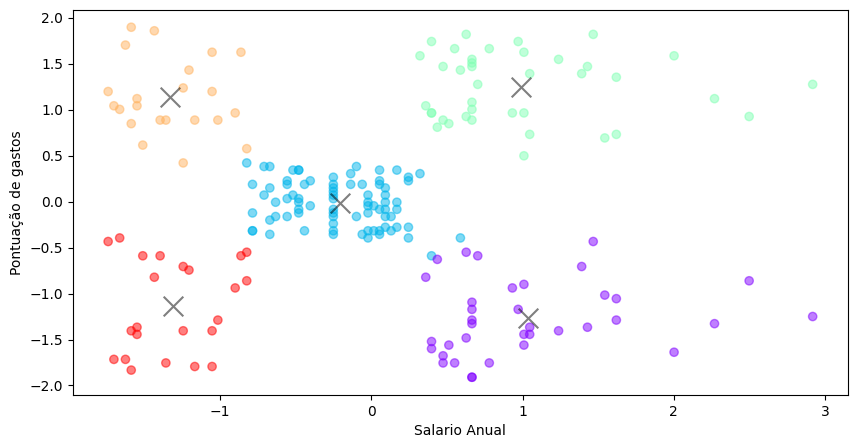

In [171]:
plt.scatter(dados_Escalonados[["Annual Income (k$)"]], dados_Escalonados[["Spending Score (1-100)"]], c=kmeans_labels_escalonado,alpha=0.5,cmap="rainbow")
plt.xlabel('Salario Anual')
plt.ylabel('Pontuação de gastos')
plt.scatter(centroides_escalonados[:,0], centroides_escalonados[:,1], c='black', marker='x',s=200, alpha=0.5)
plt.rcParams['figure.figsize'] = (10, 5)
plt.show()

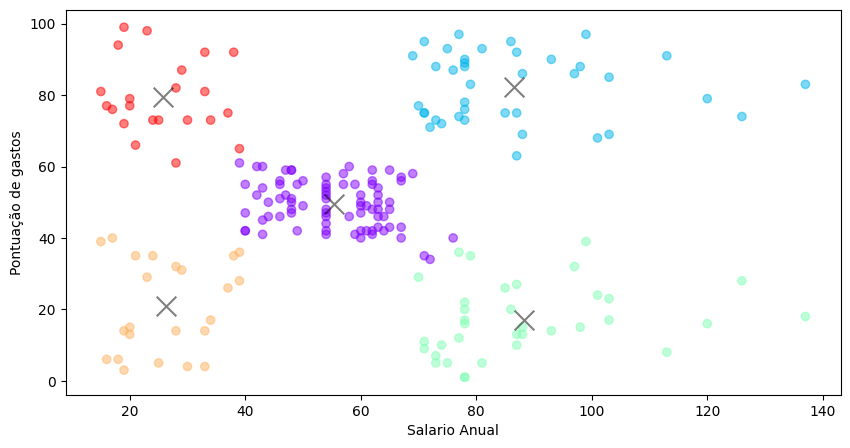

In [172]:
plt.scatter(mall[["Annual Income (k$)"]], mall[["Spending Score (1-100)"]], c=kmeans_labels,alpha=0.5,cmap="rainbow")
plt.xlabel('Salario Anual')
plt.ylabel('Pontuação de gastos')
plt.scatter(centroides[:,0], centroides[:,1], c='black', marker='x',s=200, alpha=0.5)
plt.rcParams['figure.figsize'] = (10, 5)
plt.show()

Inicialmente, o K-Means foi aplicado aos dados sem normalização apenas para fins exploratórios. Em seguida, o modelo foi treinado com dados escalonados, uma vez que o algoritmo é sensível à escala das variáveis e depende diretamente de medidas de distância. O modelo com feature scaling é considerado o mais adequado e foi utilizado para a análise final dos clusters.

In [173]:
from sklearn.metrics import adjusted_rand_score

adjusted_rand_score(kmeans_labels, kmeans_labels_escalonado)

0.9847169139719528

< 1.0 → clusters diferentes (mesmo que pareçam iguais)

In [174]:
dados_grupo_1 = mall[mall['Grupos'] == 1]

In [175]:
dados_grupo_2 = mall[mall['Grupos'] == 2]

In [176]:
dados_grupo_3 = mall[mall['Grupos'] == 3]

In [177]:
dados_grupo_4 = mall[mall['Grupos'] == 4]

In [178]:
dados_grupo_5 = mall[mall['Grupos'] == 5]

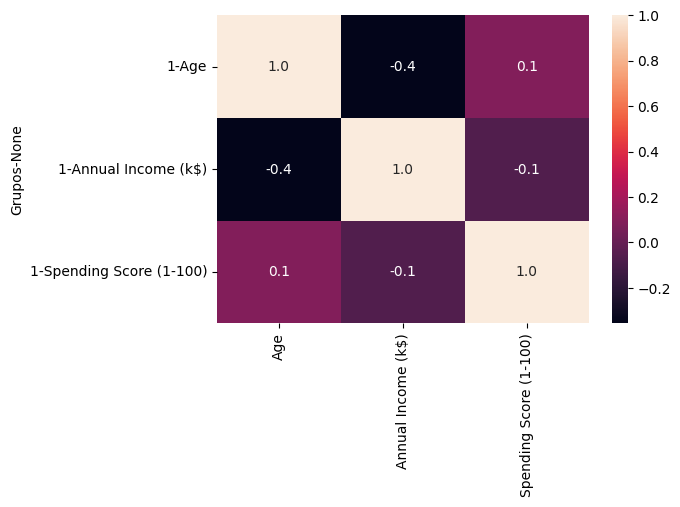

In [179]:
cols_numericas = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
plt.figure(figsize=(6,4))
sns.heatmap(dados_grupo_1.groupby('Grupos')[cols_numericas].corr(method = 'pearson'), annot=True, fmt=".1f");

### 2. DBSCAN

### Sobre o modelo
O **DBSCAN** (Density-Based Spatial Clustering of Applications with Noise) é um algoritmo de **clusterização baseado em densidade**, que forma grupos a partir de regiões com alta concentração de pontos. Ele é especialmente eficaz para **identificar ruídos (outliers)** e não exige a definição prévia do número de clusters.

O algoritmo classifica os pontos em:
- **Core**: pontos com número de vizinhos maior ou igual ao *MinPts* dentro de um raio *Eps*  
- **Border**: pontos na fronteira de um cluster  
- **Noise**: pontos isolados considerados ruído  

### Hiperparâmetros
- **Eps (ε)**: raio de vizinhança ao redor de um ponto  
- **MinPts**: número mínimo de pontos dentro do raio para formar um cluster  

### Vantagens
- Identifica e trata bem **outliers**
- Não exige definição prévia do número de clusters
- Funciona bem em bases de dados grandes

### Desvantagens
- Dificuldade em lidar com **clusters dentro de clusters**
- Desempenho limitado em dados de **alta dimensionalidade**
- Sensível à escolha do **Eps**, especialmente quando os clusters possuem densidades diferentes

In [180]:
#Criando o modelo:
dbscan = DBSCAN(eps=10, min_samples=8)
#Ajustando aos dados
dbscan.fit(mall[['Annual Income (k$)','Spending Score (1-100)']])

dbscan_labels = dbscan.labels_
dbscan_labels

array([-1,  0,  1,  0, -1,  0,  1, -1,  1,  0, -1, -1, -1,  0,  1,  0, -1,
        0, -1, -1, -1,  0,  1,  0,  1,  0, -1, -1,  2,  0,  1,  0,  1, -1,
       -1,  0, -1,  0,  2, -1,  2, -1,  2,  2,  2,  2,  2,  2,  2,  2,  2,
        2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,
        2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,
        2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,
        2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,
        2,  2,  2,  2,  3,  2,  3,  2,  3,  4,  3,  4,  3,  2,  3,  4,  3,
        4,  3,  4,  3,  4,  3,  2,  3,  4,  3,  2,  3,  4,  3,  4,  3,  4,
        3,  4,  3,  4,  3,  4,  3,  2,  3,  4,  3,  4,  3,  4,  3,  4, -1,
        4,  3,  4,  3,  4,  3,  4,  3,  4,  3, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1])

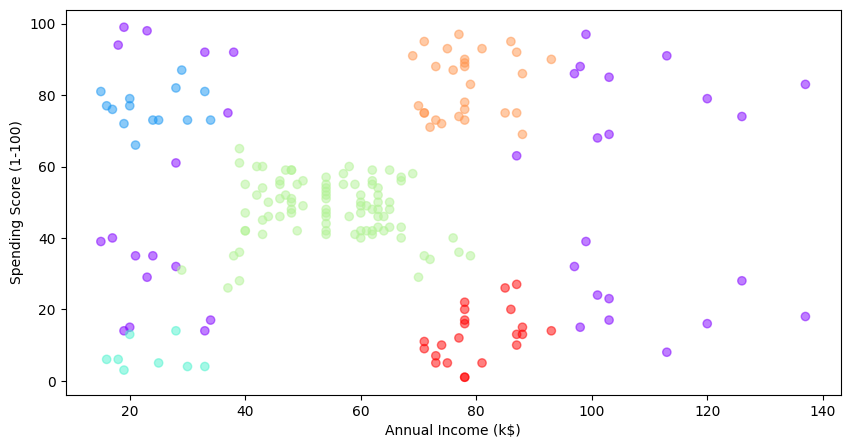

In [181]:
#Plotando o grafico:
plt.scatter(mall['Annual Income (k$)'],mall['Spending Score (1-100)'], c=dbscan_labels, alpha=0.5, cmap='rainbow')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show()

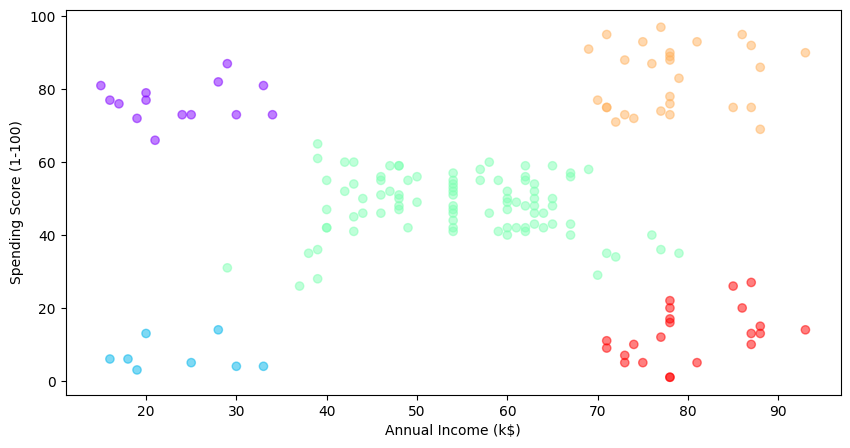

In [182]:
#Plotando o grafico sem os outliers:
#mascara para outlier
mascara = dbscan_labels>=0

#plotando o gráfico
plt.scatter(mall['Annual Income (k$)'][mascara],mall['Spending Score (1-100)'][mascara], c=dbscan_labels[mascara], alpha=0.5, cmap='rainbow')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show()

In [183]:
list(mascara).count(False)

38

In [184]:
#Criando o modelo:
dbscan_escalonados = DBSCAN(eps=0.4, min_samples=8)
#Ajustando aos dados
dbscan_escalonados.fit(dados_Escalonados[['Annual Income (k$)','Spending Score (1-100)']])

dbscan_labels_escalonados = dbscan_escalonados.labels_
dbscan_labels_escalonados

array([-1,  0,  1,  0, -1,  0,  1, -1,  1,  0,  1, -1,  1,  0,  1,  0,  2,
        0,  2, -1,  2,  0,  1,  0,  1,  0,  2, -1,  2,  0,  1,  0,  1, -1,
        1,  0,  1,  0,  2,  2,  2, -1,  2,  2,  2,  2,  2,  2,  2,  2,  2,
        2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,
        2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,
        2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,
        2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,
        2,  2,  2,  2,  3,  2,  3,  2,  3,  4,  3,  4,  3,  2,  3,  4,  3,
        4,  3,  4,  3,  4,  3,  2,  3,  4,  3,  2,  3,  4,  3,  4,  3,  4,
        3,  4,  3,  4,  3,  4,  3,  2,  3,  4,  3,  4,  3,  4,  3,  4, -1,
        4,  3,  4,  3,  4,  3,  4,  3,  4,  3, -1,  3,  4,  3, -1, -1, -1,
       -1,  4, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1])

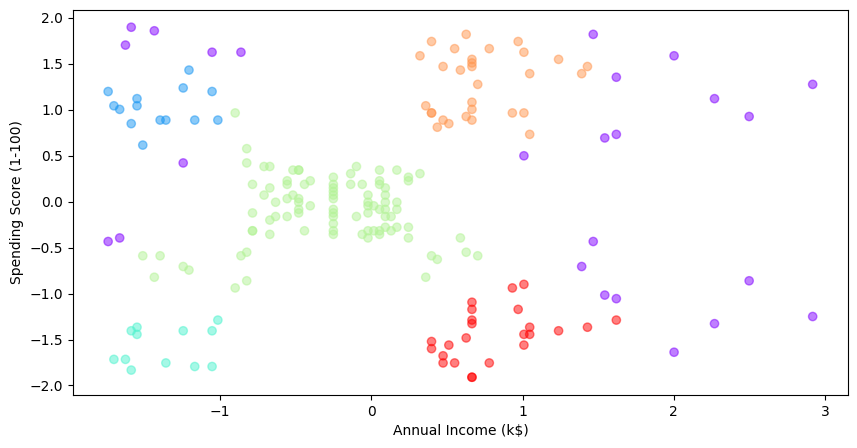

In [185]:
#Plotando o grafico:
plt.scatter(dados_Escalonados[['Annual Income (k$)']],dados_Escalonados[['Spending Score (1-100)']], c=dbscan_labels_escalonados, alpha=0.5, cmap='rainbow')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show()

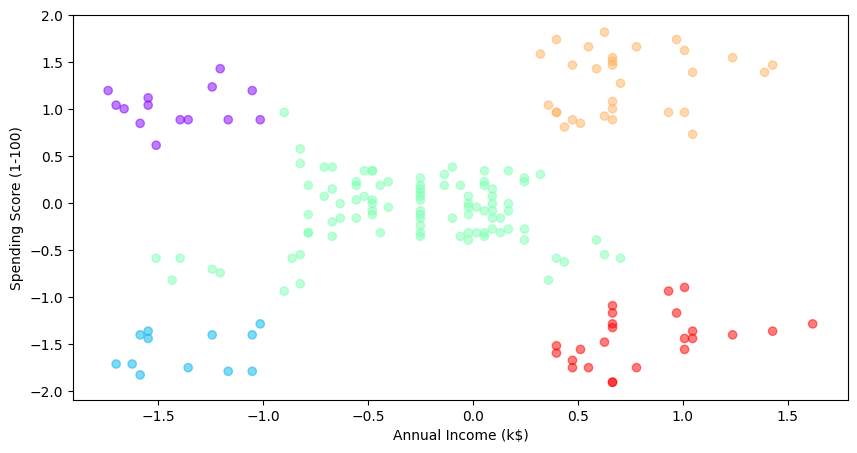

In [186]:
#Plotando o grafico sem os outliers:
#mascara para outlier
mascara = dbscan_labels_escalonados>=0

#plotando o gráfico
plt.scatter(dados_Escalonados[['Annual Income (k$)']][mascara],dados_Escalonados[['Spending Score (1-100)']][mascara], c=dbscan_labels_escalonados[mascara], alpha=0.5, cmap='rainbow')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show()

Avaliando e validando a Clusterização

(a) Usando o Adjusted Rand Index

(b) Avaliando a métrica de Silhouette

In [187]:
adjusted_rand_score(kmeans_labels,dbscan_labels)
#Compara o desempenho quando forem fornecidos datasets com labels geradas de forma aleatória. Quando essas labels estão muito diferente, o valor se aproxima de 0, o que sugere um resultado negativo, ou seja, clusters não próximos.

0.7151933782093212

In [188]:
silhouette_score(mall[['Annual Income (k$)','Spending Score (1-100)']],kmeans_labels)

np.float64(0.553931997444648)

In [189]:
mask = dbscan_labels >= 0

In [190]:
import numpy as np

In [191]:
np.unique(dbscan_labels[mask])

array([0, 1, 2, 3, 4])

In [192]:
mask = dbscan_labels >= 0
n_clusters = len(set(dbscan_labels[mask]))
n_clusters

5

In [193]:
silhouette_score(
    mall[['Annual Income (k$)','Spending Score (1-100)']][mask],
    dbscan_labels[mask]
)

np.float64(0.5870574977301237)

In [194]:
mask_escalonados = dbscan_labels_escalonados >= 0
n_clusters_escolonados = len(set(dbscan_labels_escalonados[mask]))
n_clusters_escolonados

5

In [195]:
mask_escalonados = dbscan_labels_escalonados >= 0

silhouette_score(
    dados_Escalonados[mask_escalonados],
    dbscan_labels_escalonados[mask_escalonados]
)

np.float64(0.5274182797786064)

In [196]:
## silhouette_score
# Mede o quão bem cada ponto está associado ao seu cluster
# considerando a distância média aos pontos do próprio cluster
# e aos pontos do cluster mais próximo.
# Valores próximos a 1 indicam clusters bem separados,
# próximos a 0 indicam sobreposição,
# negativos indicam má alocação.

O silhouette score foi utilizado para avaliar a qualidade dos clusters do K-Means, sendo uma métrica adequada nesse contexto, pois todos os pontos pertencem a algum grupo. Para o DBSCAN, o cálculo do silhouette exige a remoção dos pontos classificados como ruído (label = -1), uma vez que a métrica não é projetada para lidar com observações não pertencentes a clusters.